### Importación de un modelo con datos de RRHH (general_data.csv)

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt


path_filename = "general_data_.csv"
path_file =  os.path.join('', path_filename)

df = pd.read_csv(path_file, sep=',')


### Exploratory data analysis

In [2]:
df.sample(5)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
1036,41,No,Travel_Rarely,Research & Development,3,3,Life Sciences,1,1037,Male,...,3.0,Y,13,8,1,11.0,2,3,1,2
3712,31,No,Travel_Rarely,Research & Development,16,3,Medical,1,3713,Male,...,1.0,Y,19,8,1,13.0,5,13,9,9
1382,27,No,Travel_Rarely,Research & Development,5,4,Medical,1,1383,Male,...,0.0,Y,13,8,0,6.0,2,5,1,1
134,54,No,Travel_Rarely,Human Resources,9,3,Life Sciences,1,135,Female,...,4.0,Y,23,8,1,24.0,2,4,1,2
3608,43,No,Travel_Rarely,Research & Development,7,2,Medical,1,3609,Female,...,3.0,Y,18,8,2,23.0,3,21,15,17


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4410.0,36.923810,9.133301,18.0,30.00,36.0,43.00,60.0
DistanceFromHome,4410.0,9.192517,8.105026,1.0,2.00,7.0,14.00,29.0
Education,4410.0,2.912925,1.023933,1.0,2.00,3.0,4.00,5.0
EmployeeCount,4410.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeID,4410.0,2205.500000,1273.201673,1.0,1103.25,2205.5,3307.75,4410.0
JobLevel,4410.0,2.063946,1.106689,1.0,1.00,2.0,3.00,5.0
MonthlyIncome,4410.0,65029.312925,47068.888559,10090.0,29110.00,49190.0,83800.00,199990.0
NumCompaniesWorked,4391.0,2.694830,2.498887,0.0,1.00,2.0,4.00,9.0
PercentSalaryHike,4410.0,15.209524,3.659108,11.0,12.00,14.0,18.00,25.0
StandardHours,4410.0,8.000000,0.000000,8.0,8.00,8.0,8.00,8.0


In [5]:
df.nunique()

Age                          43
Attrition                     2
BusinessTravel                3
Department                    3
DistanceFromHome             29
Education                     5
EducationField                6
EmployeeCount                 1
EmployeeID                 4410
Gender                        2
JobLevel                      5
JobRole                       9
MaritalStatus                 3
MonthlyIncome              1349
NumCompaniesWorked           10
Over18                        1
PercentSalaryHike            15
StandardHours                 1
StockOptionLevel              4
TotalWorkingYears            40
TrainingTimesLastYear         7
YearsAtCompany               37
YearsSinceLastPromotion      16
YearsWithCurrManager         18
dtype: int64

In [6]:
df[['EmployeeCount','Over18','StandardHours']]

,EmployeeCount,Over18,StandardHours
0,1,Y,8
1,1,Y,8
2,1,Y,8
3,1,Y,8
4,1,Y,8
...,...,...,...
4405,1,Y,8
4406,1,Y,8
4407,1,Y,8
4408,1,Y,8


### Validación de datos

In [7]:
df.shape

(4410, 24)

In [8]:
print('Existen',df.isnull().sum().sum(),'valores no definidos')

Existen 28 valores no definidos


In [9]:
missing_values_count = df.isnull().sum()
print('Columnas que tienen valores nulos')
print('---------------------------------------')
missing_values_count

Columnas que tienen valores nulos
---------------------------------------


Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeID                  0
Gender                      0
JobLevel                    0
JobRole                     0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked         19
Over18                      0
PercentSalaryHike           0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           9
TrainingTimesLastYear       0
YearsAtCompany              0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [10]:
df.columns[missing_values_count.to_numpy().nonzero()]

Index(['NumCompaniesWorked', 'TotalWorkingYears'], dtype='object')

### Imputación de datos

In [11]:
num_comp_worked_mean = int(df['NumCompaniesWorked'].mean())
num_total_working_years_mean = int(df['TotalWorkingYears'].mean())

df['NumCompaniesWorked'] = df['NumCompaniesWorked'].fillna(num_comp_worked_mean)
df['TotalWorkingYears'] = df['TotalWorkingYears'].fillna(num_total_working_years_mean)

In [12]:
missing_values_count = df.isnull().sum()
print('Columnas que tienen valores nulos')
print('---------------------------------------')
missing_values_count

Columnas que tienen valores nulos
---------------------------------------


Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EmployeeCount              0
EmployeeID                 0
Gender                     0
JobLevel                   0
JobRole                    0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
Over18                     0
PercentSalaryHike          0
StandardHours              0
StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

In [13]:
import numpy as np
total_cells = np.prod(df.shape)
total_missing = missing_values_count.sum()

percent_missing = (total_missing/total_cells)*100
print(f"% Datos no existentes:{percent_missing:.2f}%")

% Datos no existentes:0.00%


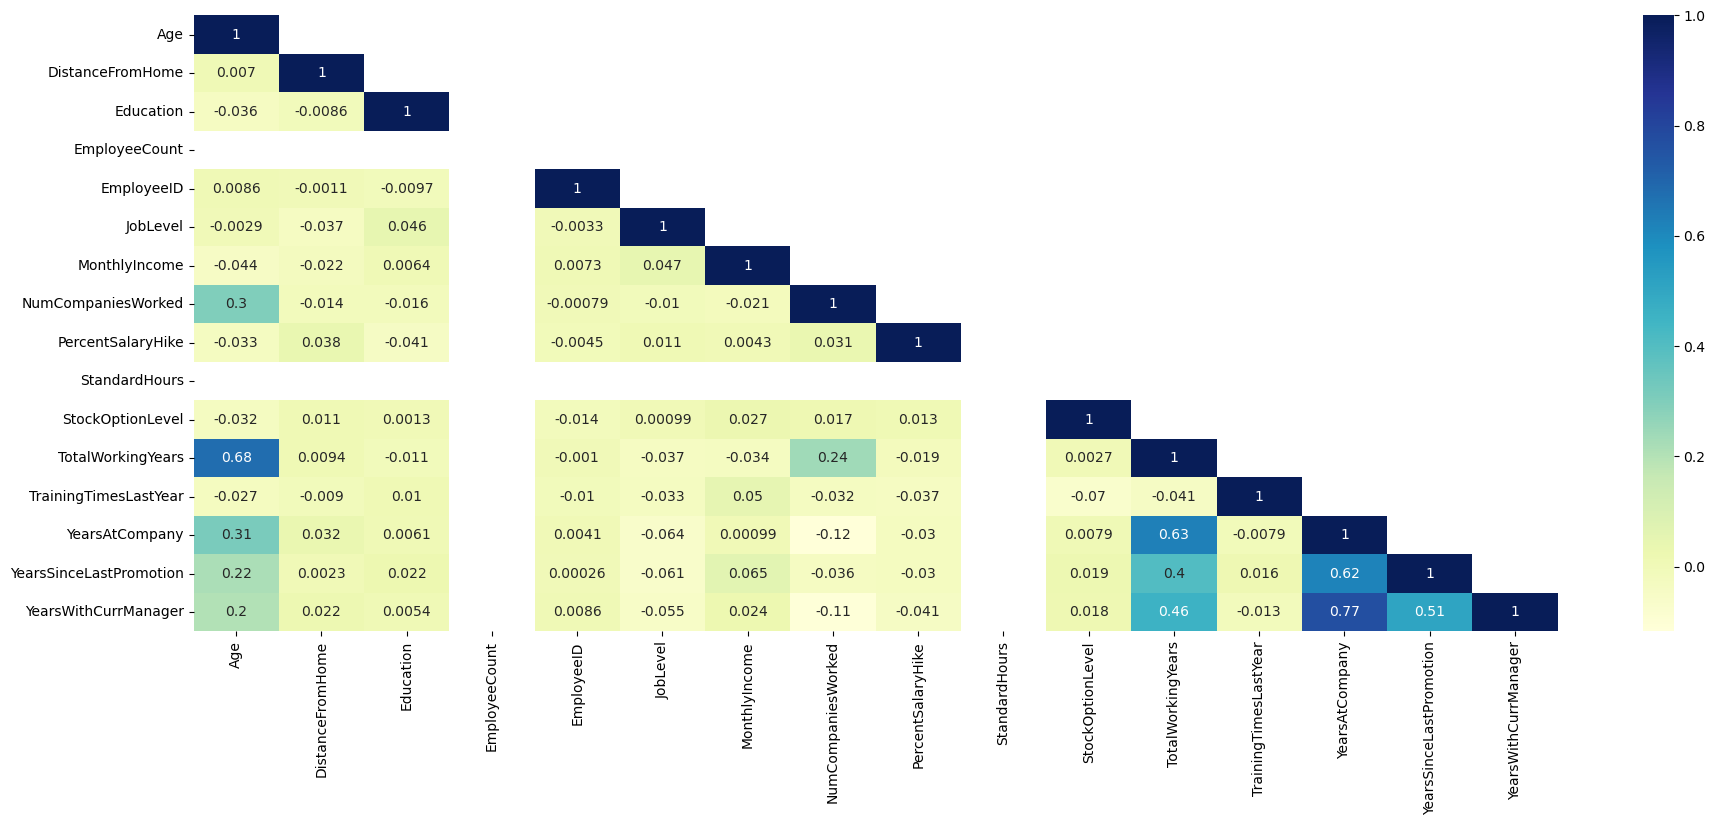

In [14]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22,8))
corr_df = corr = df.corr(numeric_only=True,method='pearson')
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap = sns.heatmap(df_lt, cmap='YlGnBu',annot=True)

### Gráfica por distribución

In [15]:
numerics = ['int16', 'int32','int64','float64']
df.select_dtypes(include=numerics).sample(5)

,Age,DistanceFromHome,Education,EmployeeCount,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
3627,50,20,2,1,3628,5,154020,4.0,21,8,0,25.0,3,3,1,2
216,24,1,3,1,217,1,34070,1.0,15,8,2,6.0,2,6,1,4
1193,38,23,3,1,1194,3,39040,1.0,22,8,0,10.0,3,10,1,9
562,35,9,2,1,563,1,104960,1.0,13,8,1,5.0,2,5,0,2
3096,24,27,2,1,3097,1,104220,1.0,17,8,1,6.0,0,5,1,4


In [16]:
cols_num = df.columns[[np.issubdtype(dt,np.number) for dt in df.dtypes]]

In [17]:
cols_num

Index(['Age', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeID',
       'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

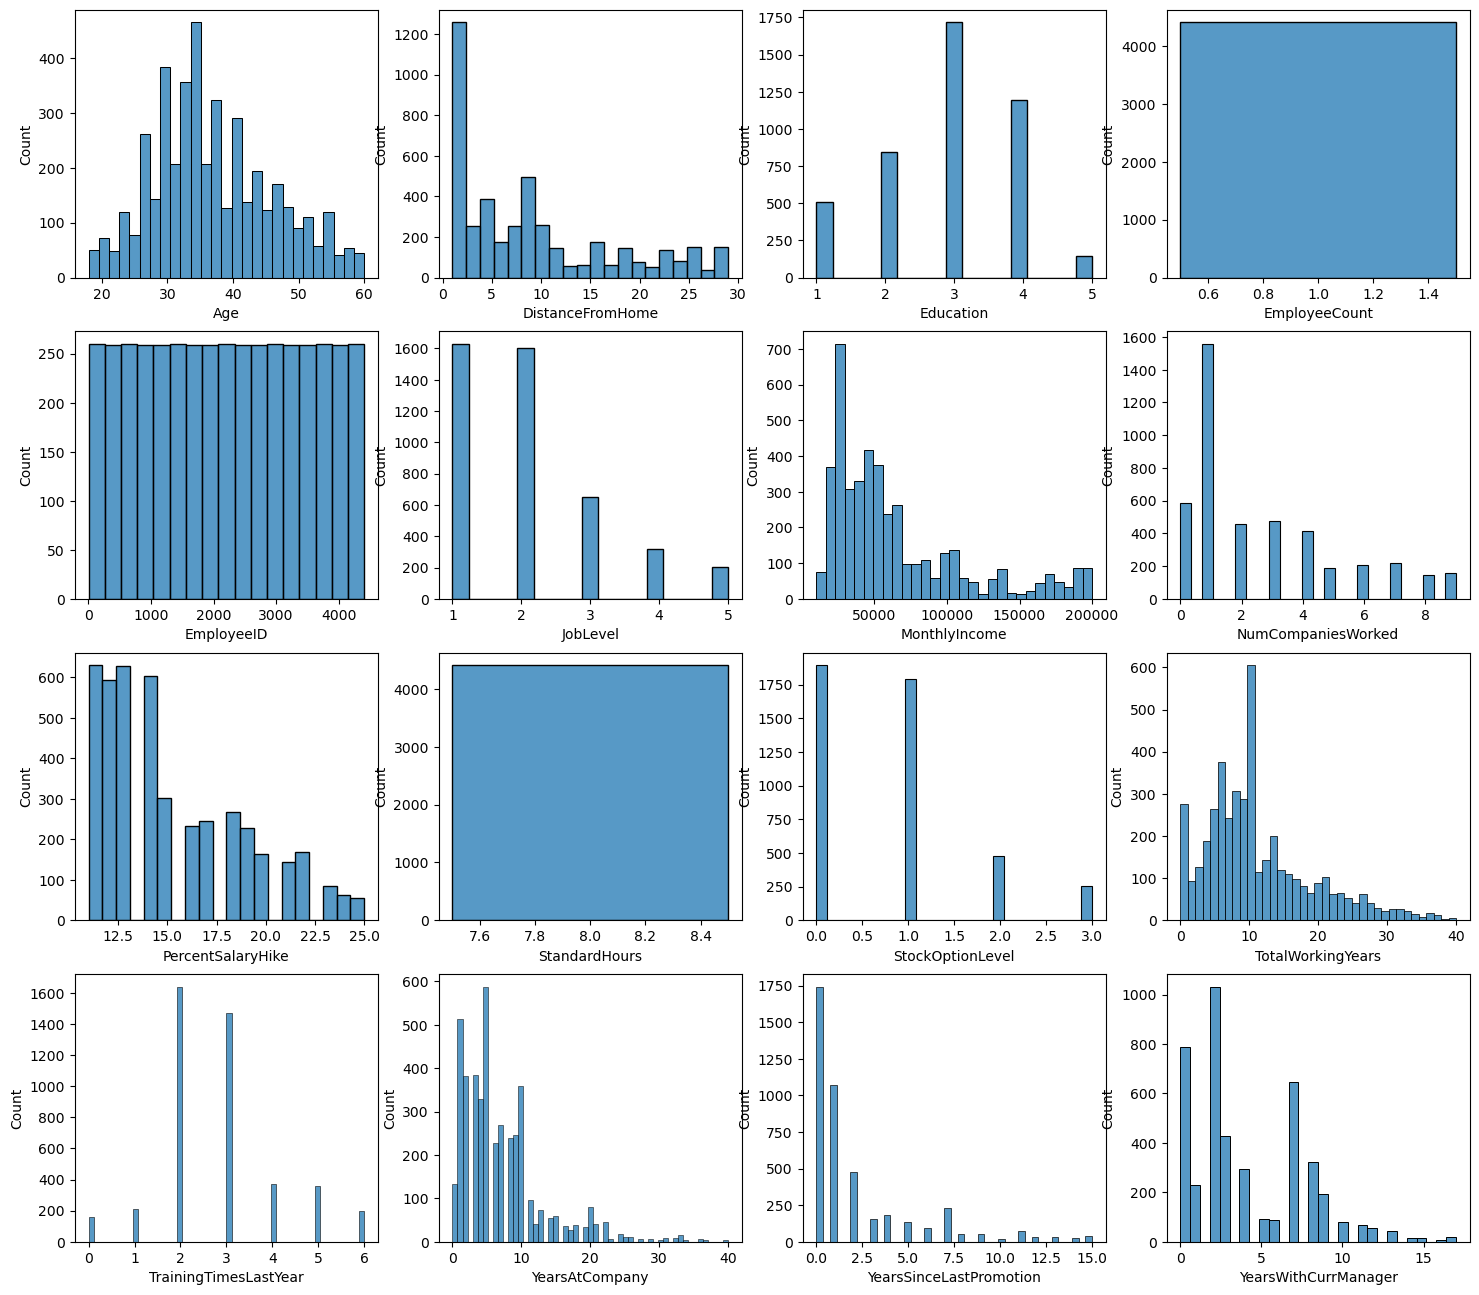

In [18]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18,16))
for i, column in enumerate(cols_num):
    sns.histplot(df[column],ax=axes[i//4,i%4],kde=False)

### Análisis bivariado

In [19]:
df.groupby(['YearsAtCompany']).mean(numeric_only=True).T

YearsAtCompany,0,1,2,3,4,5,6,7,8,9,...,27,29,30,31,32,33,34,36,37,40
Age,31.227273,35.058480,34.708661,35.125000,36.572727,36.862245,35.447368,35.988889,36.987500,39.048780,...,50.0,55.5,50.0,52.333333,50.666667,52.6,52.0,55.0,58.0,58.0
DistanceFromHome,7.204545,8.040936,9.960630,10.015625,10.790909,8.663265,8.407895,9.911111,8.737500,8.329268,...,6.0,12.0,3.0,20.666667,4.333333,13.6,21.0,12.5,8.0,2.0
Education,3.227273,2.853801,2.952756,2.992188,2.900000,2.821429,2.842105,2.811111,2.850000,2.939024,...,4.0,3.0,3.0,2.333333,3.000000,3.0,5.0,2.5,4.0,2.0
EmployeeCount,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0
EmployeeID,2157.613636,2198.777778,2215.937008,2192.351562,2254.445455,2200.653061,2178.013158,2199.677778,2075.462500,2275.353659,...,2191.5,1877.5,2351.0,1786.666667,1983.666667,2483.8,1774.0,1906.0,2781.0,2809.0
JobLevel,1.818182,2.140351,2.039370,2.132812,2.381818,2.040816,1.960526,2.100000,1.925000,2.268293,...,3.5,1.5,2.0,1.333333,2.000000,2.2,3.0,1.0,2.0,1.0
MonthlyIncome,62946.136364,64813.040936,60889.370079,70544.843750,62060.545455,60875.357143,66514.605263,65454.666667,64735.875000,64392.073171,...,65815.0,63980.0,42940.0,42086.666667,22406.666667,46374.0,28890.0,41155.0,29720.0,43850.0
NumCompaniesWorked,2.916667,2.951267,3.519685,3.023438,3.112121,2.770408,2.368421,2.859259,2.687500,1.621951,...,2.5,4.5,2.0,3.000000,1.000000,0.6,1.0,0.5,0.0,1.0
PercentSalaryHike,16.159091,14.877193,15.503937,15.125000,15.700000,15.056122,15.565789,15.333333,15.450000,15.365854,...,13.0,16.0,20.0,18.333333,13.000000,17.4,11.0,17.5,14.0,13.0
StandardHours,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,8.0,8.0,8.0,8.000000,8.000000,8.0,8.0,8.0,8.0,8.0


In [20]:
df.groupby(['JobLevel']).mean(numeric_only=True).T

JobLevel,1,2,3,4,5
Age,36.775322,37.367041,36.266055,36.377358,37.579710
DistanceFromHome,9.381215,9.415730,8.784404,8.273585,8.681159
Education,2.841621,2.945693,2.940367,3.047170,2.927536
EmployeeCount,1.000000,1.000000,1.000000,1.000000,1.000000
EmployeeID,2189.810313,2237.709738,2196.220183,2142.886792,2205.202899
MonthlyIncome,62677.421731,65506.479401,63545.321101,77940.754717,64698.405797
NumCompaniesWorked,2.669122,2.742821,2.772171,2.443396,2.603865
PercentSalaryHike,14.963168,15.475655,15.412844,14.783019,15.101449
StandardHours,8.000000,8.000000,8.000000,8.000000,8.000000
StockOptionLevel,0.823204,0.758427,0.793578,0.716981,0.956522


In [21]:
df.groupby(['StockOptionLevel']).mean(numeric_only=True)[['Age','DistanceFromHome','MonthlyIncome','TotalWorkingYears']]

,Age,DistanceFromHome,MonthlyIncome,TotalWorkingYears
StockOptionLevel,,,,
0,36.939778,9.169572,63077.606973,11.159007
1,37.278523,9.156040,66549.630872,11.378076
2,36.354430,9.025316,66898.924051,11.810127
3,35.376471,9.929412,65382.470588,10.494118


In [22]:
df.groupby(['StockOptionLevel']).median(numeric_only=True)[['Age','DistanceFromHome','MonthlyIncome','TotalWorkingYears']]

,Age,DistanceFromHome,MonthlyIncome,TotalWorkingYears
StockOptionLevel,,,,
0,36.0,7.0,47410.0,10.0
1,36.0,7.0,50790.0,10.0
2,36.0,7.0,49985.0,10.0
3,35.0,8.0,46800.0,9.0


In [23]:
df.groupby(['DistanceFromHome']).mean(numeric_only=True)[['Age','YearsAtCompany','MonthlyIncome','StockOptionLevel','TotalWorkingYears']]

,Age,YearsAtCompany,MonthlyIncome,StockOptionLevel,TotalWorkingYears
DistanceFromHome,,,,,
1,36.975962,6.711538,74225.961538,0.836538,11.035256
2,37.118483,6.995261,61561.184834,0.800948,11.507109
3,36.869048,7.511905,57366.666667,0.809524,11.321429
4,38.296875,6.546875,67159.531250,0.562500,11.718750
5,37.307692,6.876923,65834.615385,0.692308,11.384615
6,37.186441,8.525424,56150.847458,0.881356,12.542373
7,35.250000,6.035714,61265.000000,0.785714,10.095238
8,36.137500,5.875000,66123.125000,0.675000,10.412500
9,36.823529,5.517647,70304.588235,0.764706,10.305882


### Feature Engineering

In [24]:
df2 = df.copy()

In [25]:
df2.sample(5)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
1673,35,No,Travel_Rarely,Research & Development,16,4,Medical,1,1674,Male,...,1.0,Y,15,8,0,5.0,2,5,0,3
2423,37,No,Travel_Frequently,Research & Development,13,3,Life Sciences,1,2424,Male,...,1.0,Y,12,8,1,6.0,4,6,1,3
240,22,No,Travel_Rarely,Research & Development,2,2,Medical,1,241,Female,...,0.0,Y,14,8,0,3.0,3,2,2,2
4337,33,No,Travel_Rarely,Research & Development,4,3,Life Sciences,1,4338,Male,...,1.0,Y,11,8,3,8.0,6,8,1,6
304,33,Yes,Travel_Rarely,Research & Development,1,2,Medical,1,305,Male,...,1.0,Y,17,8,3,10.0,2,10,7,8


In [26]:
df2.drop('EmployeeID',axis=1,inplace=True)
df2.drop('StandardHours',axis=1,inplace=True)
df2.drop('Over18',axis=1,inplace=True)
df2.drop('EmployeeCount',axis=1,inplace=True)

In [27]:
df2['BusinessTravel'] = df2['BusinessTravel'].astype('category')
df2['Department'] = df2['Department'].astype('category')
df2['EducationField'] = df2['EducationField'].astype('category')
df2['Gender'] = df2['Gender'].astype('category')

df2['NumCompaniesWorked'] = df2['NumCompaniesWorked'].fillna(0).astype(np.int64)

In [28]:
df2.sample(3)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
1154,30,No,Travel_Rarely,Human Resources,20,4,Life Sciences,Male,2,Research Scientist,Married,46610,1,11,0,12.0,3,12,1,7
4367,41,No,Travel_Rarely,Research & Development,1,3,Life Sciences,Male,2,Human Resources,Single,68830,3,19,2,16.0,3,1,0,0
3336,39,No,Travel_Rarely,Research & Development,1,3,Other,Female,3,Human Resources,Married,68040,8,14,1,13.0,3,5,0,4


In [29]:
print(df2['EducationField'].value_counts())
print('')

print(df2['BusinessTravel'].value_counts())
print('')

print(df2['Department'].value_counts())
print('')


EducationField
Life Sciences       1818
Medical             1392
Marketing            477
Technical Degree     396
Other                246
Human Resources       81
Name: count, dtype: int64

BusinessTravel
Travel_Rarely        3129
Travel_Frequently     831
Non-Travel            450
Name: count, dtype: int64

Department
Research & Development    2883
Sales                     1338
Human Resources            189
Name: count, dtype: int64



In [30]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      4410 non-null   int64   
 1   Attrition                4410 non-null   object  
 2   BusinessTravel           4410 non-null   category
 3   Department               4410 non-null   category
 4   DistanceFromHome         4410 non-null   int64   
 5   Education                4410 non-null   int64   
 6   EducationField           4410 non-null   category
 7   Gender                   4410 non-null   category
 8   JobLevel                 4410 non-null   int64   
 9   JobRole                  4410 non-null   object  
 10  MaritalStatus            4410 non-null   object  
 11  MonthlyIncome            4410 non-null   int64   
 12  NumCompaniesWorked       4410 non-null   int64   
 13  PercentSalaryHike        4410 non-null   int64   
 14  StockOpt

In [31]:
df2['Attrition'] = df2['Attrition'].replace({'Yes':1,'No':0},regex=True)

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_10387/2420509287.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2['Attrition'] = df2['Attrition'].replace({'Yes':1,'No':0},regex=True)


In [32]:
df2['Gender'] = df2['Gender'].astype('category').cat.codes
df2['EducationField'] = df2['EducationField'].astype('category').cat.codes
df2['BusinessTravel'] = df2['BusinessTravel'].astype('category').cat.codes
df2['Department'] = df2['Department'].astype('category').cat.codes
df2['MaritalStatus'] = df2['MaritalStatus'].astype('category').cat.codes
df2['JobRole'] = df2['JobRole'].astype('category').cat.codes

In [33]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   int64  
 2   BusinessTravel           4410 non-null   int8   
 3   Department               4410 non-null   int8   
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   int8   
 7   Gender                   4410 non-null   int8   
 8   JobLevel                 4410 non-null   int64  
 9   JobRole                  4410 non-null   int8   
 10  MaritalStatus            4410 non-null   int8   
 11  MonthlyIncome            4410 non-null   int64  
 12  NumCompaniesWorked       4410 non-null   int64  
 13  PercentSalaryHike        4410 non-null   int64  
 14  StockOptionLevel        

In [34]:
df2.sample(10)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
3171,43,0,2,1,10,5,5,0,2,7,0,26830,4,11,0,21.0,3,1,0,0
846,29,0,2,1,23,4,1,0,2,0,1,45370,6,18,1,5.0,5,1,0,0
534,33,1,1,1,1,2,1,0,1,7,2,62140,1,19,2,14.0,3,13,3,8
1524,31,0,2,2,16,4,2,0,2,6,0,28040,0,19,2,3.0,0,2,2,2
3077,43,0,1,2,14,3,1,0,1,4,1,37480,7,14,2,8.0,3,3,1,2
4098,38,0,2,1,19,3,1,0,2,7,1,68930,0,17,0,16.0,3,15,5,8
14,28,0,2,1,1,3,1,1,1,4,1,25920,1,14,0,5.0,2,5,0,4
513,54,0,2,1,5,3,3,0,2,4,1,24780,6,11,0,13.0,0,9,7,0
1913,53,0,2,1,9,3,5,1,1,3,0,39200,6,16,1,22.0,3,17,15,2
3993,18,0,0,1,2,3,1,1,3,8,2,186060,1,24,2,0.0,4,0,0,0


In [35]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   int64  
 2   BusinessTravel           4410 non-null   int8   
 3   Department               4410 non-null   int8   
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   int8   
 7   Gender                   4410 non-null   int8   
 8   JobLevel                 4410 non-null   int64  
 9   JobRole                  4410 non-null   int8   
 10  MaritalStatus            4410 non-null   int8   
 11  MonthlyIncome            4410 non-null   int64  
 12  NumCompaniesWorked       4410 non-null   int64  
 13  PercentSalaryHike        4410 non-null   int64  
 14  StockOptionLevel        

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df2['MonthlyIncome_scale'] = StandardScaler().fit_transform(df2[['MonthlyIncome']])

In [37]:
df2.drop('MonthlyIncome',axis=1,inplace=True)

In [38]:
df.sample(10)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
1636,57,No,Travel_Rarely,Research & Development,2,2,Life Sciences,1,1637,Male,...,3.0,Y,12,8,1,32.0,3,1,0,0
1009,34,No,Non-Travel,Research & Development,7,4,Medical,1,1010,Female,...,1.0,Y,21,8,0,15.0,5,15,0,7
2940,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,2941,Female,...,1.0,Y,11,8,0,1.0,6,1,0,0
592,32,No,Non-Travel,Research & Development,11,2,Other,1,593,Female,...,1.0,Y,11,8,0,1.0,5,1,0,0
1396,53,No,Travel_Rarely,Sales,1,2,Life Sciences,1,1397,Male,...,1.0,Y,13,8,0,5.0,2,4,1,3
2588,38,No,Travel_Rarely,Research & Development,3,4,Life Sciences,1,2589,Female,...,2.0,Y,21,8,1,10.0,1,5,0,3
92,42,No,Travel_Rarely,Sales,7,4,Medical,1,93,Male,...,0.0,Y,12,8,1,4.0,3,3,1,0
2012,28,Yes,Travel_Frequently,Research & Development,7,3,Life Sciences,1,2013,Male,...,1.0,Y,14,8,0,1.0,3,1,0,0
2978,18,Yes,Travel_Rarely,Research & Development,1,4,Life Sciences,1,2979,Male,...,1.0,Y,14,8,2,0.0,3,0,0,0
1008,41,No,Travel_Rarely,Research & Development,5,3,Medical,1,1009,Male,...,1.0,Y,19,8,0,5.0,2,5,0,4


In [39]:
df2.nunique()

Age                          43
Attrition                     2
BusinessTravel                3
Department                    3
DistanceFromHome             29
Education                     5
EducationField                6
Gender                        2
JobLevel                      5
JobRole                       9
MaritalStatus                 3
NumCompaniesWorked           10
PercentSalaryHike            15
StockOptionLevel              4
TotalWorkingYears            40
TrainingTimesLastYear         7
YearsAtCompany               37
YearsSinceLastPromotion      16
YearsWithCurrManager         18
MonthlyIncome_scale        1349
dtype: int64

In [40]:
cols_num = df2.columns[[np.issubdtype(dt,np.number) for dt in df2.dtypes]]
len(cols_num)

20

In [41]:
df2.nunique()

Age                          43
Attrition                     2
BusinessTravel                3
Department                    3
DistanceFromHome             29
Education                     5
EducationField                6
Gender                        2
JobLevel                      5
JobRole                       9
MaritalStatus                 3
NumCompaniesWorked           10
PercentSalaryHike            15
StockOptionLevel              4
TotalWorkingYears            40
TrainingTimesLastYear         7
YearsAtCompany               37
YearsSinceLastPromotion      16
YearsWithCurrManager         18
MonthlyIncome_scale        1349
dtype: int64

In [42]:
print('Columnas que tienen valores nulos')
print('----------------------------------------')

missing_values_count

Columnas que tienen valores nulos
----------------------------------------


Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EmployeeCount              0
EmployeeID                 0
Gender                     0
JobLevel                   0
JobRole                    0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
Over18                     0
PercentSalaryHike          0
StandardHours              0
StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

In [43]:
num_total_working_years_mean = int(df2['TotalWorkingYears'].mean())
df2['TotalWorkingYears'] = df2['TotalWorkingYears'].fillna(num_total_working_years_mean)

KeyError: 'MonthlyIncome_scale'

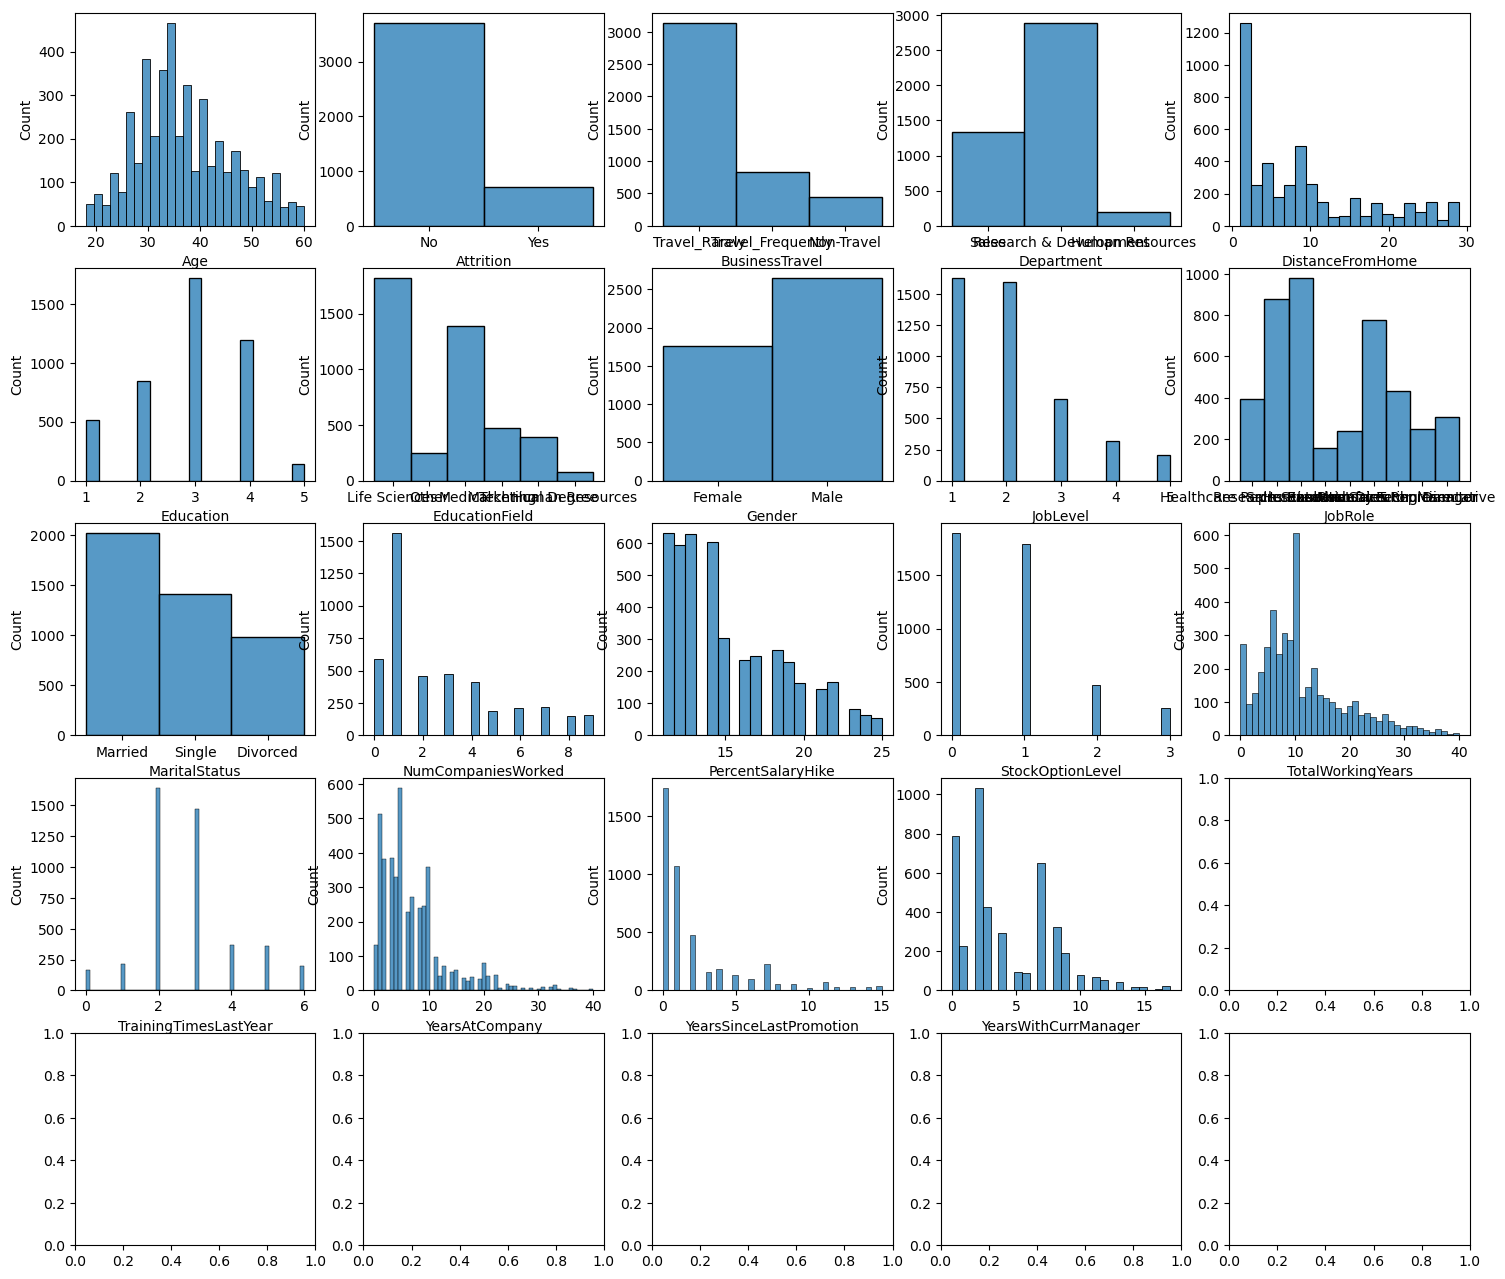

In [45]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(18,16))
for i, column in enumerate(cols_num):
    sns.histplot(df[column],ax=axes[i//5,i%5],kde=False)

### Data Split

In [46]:
from sklearn.model_selection import train_test_split

X = df2.drop('Attrition',axis=1)
y = df2['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30, random_state=1)

In [47]:
X.head(5)

,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,MaritalStatus,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,MonthlyIncome_scale
0,51,2,2,6,2,1,0,1,0,1,1,11,0,1.0,6,1,0,0,1.405136
1,31,1,1,10,1,1,0,1,6,2,0,23,1,6.0,3,5,1,4,-0.491661
2,32,1,1,17,4,4,1,4,7,1,1,15,3,5.0,2,5,0,3,2.725053
3,38,0,1,2,5,1,1,3,1,1,3,11,3,13.0,5,8,7,5,0.386301
4,32,2,1,10,1,3,1,1,7,2,4,12,2,9.0,2,6,0,4,-0.884109


In [48]:
y.head(10)

0    0
1    1
2    0
3    0
4    0
5    0
6    1
7    0
8    0
9    0
Name: Attrition, dtype: int64

In [49]:
print(df2['Attrition'].value_counts())
print(df2['Attrition'].value_counts(normalize=True))

Attrition
0    3699
1     711
Name: count, dtype: int64
Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64


In [50]:
from sklearn import metrics
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    solver='liblinear',
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)
y_predict = model.predict(X_test)

In [51]:
y_predict[:200]

array([0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1])

In [52]:
z = X_test.copy()
z['Attrition real'] = y_test
z['Attrition predicción'] = y_predict
z[['Attrition real','Attrition predicción']].head(20)

,Attrition real,Attrition predicción
2016,0,0
4118,0,1
219,0,0
4402,1,0
787,0,0
200,0,0
2539,0,0
3744,0,1
1891,0,1
3963,1,1


In [53]:
coef_df = pd.DataFrame(model.coef_)
coef_df.columns = X.columns

coef_df['intercept'] = model.intercept_
coef_df.T

,0
Age,-0.026643
BusinessTravel,0.018679
Department,-0.284458
DistanceFromHome,0.001540
Education,-0.040470
EducationField,-0.079892
Gender,0.124840
JobLevel,-0.073879
JobRole,0.052852
MaritalStatus,0.624617


Text(0.5, 1.0, 'Matriz de Confusión')

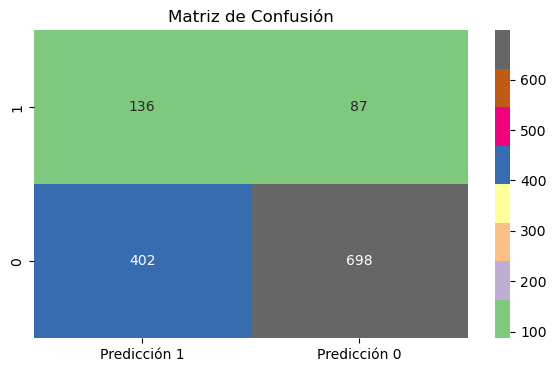

In [54]:
cm = metrics.confusion_matrix(y_test,y_predict,labels=[1,0])

df_cm = pd.DataFrame(cm,index=[i for i in ['1','0']], columns=[i for i in ['Predicción 1','Predicción 0']])

plt.figure(figsize=(7,4))
sns.heatmap(df_cm,annot=True,cmap='Accent',fmt='d').set_title('Matriz de Confusión')

In [55]:
TP = df_cm.iloc[0][0]
FP = df_cm.iloc[0][1]
FN = df_cm.iloc[1][0]
TN = df_cm.iloc[1][1]

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_10387/2489800096.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  TP = df_cm.iloc[0][0]
/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_10387/2489800096.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  FP = df_cm.iloc[0][1]
/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_10387/2489800096.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  FN = df_

In [56]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report,confusion_matrix

y_pred = model.predict(X_test)
model_score = accuracy_score(y_test, y_pred)
recall_score = recall_score(y_test,y_pred)
precision_score = precision_score(y_test,y_pred)
f1_score = f1_score(y_test,y_pred)
roc_auc_score = roc_auc_score(y_test,y_pred)

print('Medidas del modelo')
print('----------------------------')
print('Accuracy = {0:0.2f}'.format(model_score))
print('Precision = {0:0.2f}'.format(precision_score))
print('Recall = {0:0.2f}'.format(recall_score))
print('F1 Score = {0:0.2f}'.format(f1_score))
print('Roc Auc Score = {0:0.2f}'.format(roc_auc_score))


Medidas del modelo
----------------------------
Accuracy = 0.63
Precision = 0.25
Recall = 0.61
F1 Score = 0.36
Roc Auc Score = 0.62


In [57]:
model = LogisticRegression(solver='liblinear')
model.fit(X_train,y_train)
y_predict = model.predict(X_test)